# Experiment: BTC vs BTC+GLD vs BTC+GLD+USO

Aquest notebook executa un experiment amb tres conjunts d'informació:

1. **BTC**: només informació de Bitcoin.
2. **BTC+GLD**: Bitcoin + or mitjançant l'ETF GLD.
3. **BTC+GLD+USO**: Bitcoin + or + petroli mitjançant l'ETF USO.

L'entorn utilitzat és `trading_env_holding_penalty.py`, que penalitza el manteniment prolongat de posicions per evitar estratègies passives de tipus *buy-and-hold*.

In [1]:
import sys
from pathlib import Path

import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Ensure project root is available for imports when running from notebooks/
project_root = Path.cwd().parent
if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

from env.trading_env_holding_penalty import TradingEnv
from stable_baselines3 import PPO

## 1. Configuració de l'experiment

In [2]:
EXPERIMENT_NAME = "macro_gld_uso_holding_penalty"
REWARD_TYPE = "holding_penalty"
TRANSACTION_COST = 0.0
TOTAL_TIMESTEPS = 50000
ALPHA = 0.05
BETA = 0.001
TRAIN_SPLIT = 0.8

print("Experiment:", EXPERIMENT_NAME)
print("Reward:", REWARD_TYPE)
print("Transaction cost:", TRANSACTION_COST)
print("Timesteps:", TOTAL_TIMESTEPS)
print("Alpha:", ALPHA)
print("Beta:", BETA)
print("Train split:", TRAIN_SPLIT)

Experiment: macro_gld_uso_holding_penalty
Reward: holding_penalty
Transaction cost: 0.0
Timesteps: 50000
Alpha: 0.05
Beta: 0.001
Train split: 0.8


## 2. Descàrrega de dades

S'utilitzen dades horàries dels darrers 730 dies:

- BTC-USD: Bitcoin.
- GLD: ETF utilitzat com a proxy de l'or.
- USO: ETF utilitzat com a proxy del petroli.

In [3]:
btc = yf.download("BTC-USD", period="730d", interval="1h", auto_adjust=False)
gld = yf.download("GLD", period="730d", interval="1h", auto_adjust=False)
uso = yf.download("USO", period="730d", interval="1h", auto_adjust=False)

print("BTC shape:", btc.shape)
print("GLD shape:", gld.shape)
print("USO shape:", uso.shape)

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed

BTC shape: (17353, 6)
GLD shape: (5077, 6)
USO shape: (5078, 6)


## 3. Neteja de columnes

In [4]:
# yfinance may return MultiIndex columns. Keep only price level.
btc.columns = btc.columns.get_level_values(0)
gld.columns = gld.columns.get_level_values(0)
uso.columns = uso.columns.get_level_values(0)

btc.columns.name = None
gld.columns.name = None
uso.columns.name = None

print(btc.columns)
print(gld.columns)
print(uso.columns)

btc.head(), gld.head(), uso.head()

Index(['Adj Close', 'Close', 'High', 'Low', 'Open', 'Volume'], dtype='object')
Index(['Adj Close', 'Close', 'High', 'Low', 'Open', 'Volume'], dtype='object')
Index(['Adj Close', 'Close', 'High', 'Low', 'Open', 'Volume'], dtype='object')


(                              Adj Close         Close          High  \
 Datetime                                                              
 2024-04-27 00:00:00+00:00  62937.859375  62937.859375  63894.988281   
 2024-04-27 01:00:00+00:00  62559.429688  62559.429688  63217.339844   
 2024-04-27 02:00:00+00:00  62934.085938  62934.085938  63265.148438   
 2024-04-27 03:00:00+00:00  63071.062500  63071.062500  63125.246094   
 2024-04-27 04:00:00+00:00  62996.097656  62996.097656  63115.500000   
 
                                     Low          Open     Volume  
 Datetime                                                          
 2024-04-27 00:00:00+00:00  62852.578125  63753.121094          0  
 2024-04-27 01:00:00+00:00  62517.667969  63134.039062  580343808  
 2024-04-27 02:00:00+00:00  62509.085938  62581.515625  270473216  
 2024-04-27 03:00:00+00:00  62858.570312  62927.632812          0  
 2024-04-27 04:00:00+00:00  62939.726562  63065.574219          0  ,
                 

## 4. Normalització temporal i sincronització

BTC cotitza 24/7, mentre que GLD i USO cotitzen en horari de mercat. Per garantir comparabilitat, es construeix un índex temporal comú.

In [5]:
btc_1h = btc[["Close"]].copy()
gld_1h = gld[["Close"]].copy()
uso_1h = uso[["Close"]].copy()

btc_1h.index = btc_1h.index.floor("1h")
gld_1h.index = gld_1h.index.floor("1h")
uso_1h.index = uso_1h.index.floor("1h")

btc_1h = btc_1h.rename(columns={"Close": "btc_close"})
gld_1h = gld_1h.rename(columns={"Close": "gld_close"})
uso_1h = uso_1h.rename(columns={"Close": "uso_close"})

print(btc_1h.head())
print(gld_1h.head())
print(uso_1h.head())

                              btc_close
Datetime                               
2024-04-27 00:00:00+00:00  62937.859375
2024-04-27 01:00:00+00:00  62559.429688
2024-04-27 02:00:00+00:00  62934.085938
2024-04-27 03:00:00+00:00  63071.062500
2024-04-27 04:00:00+00:00  62996.097656
                            gld_close
Datetime                             
2023-05-26 13:00:00+00:00  180.960007
2023-05-26 14:00:00+00:00  180.419998
2023-05-26 15:00:00+00:00  180.740005
2023-05-26 16:00:00+00:00  180.600006
2023-05-26 17:00:00+00:00  180.789993
                           uso_close
Datetime                            
2023-05-26 13:00:00+00:00  64.769997
2023-05-26 14:00:00+00:00  64.739998
2023-05-26 15:00:00+00:00  64.739998
2023-05-26 16:00:00+00:00  64.529999
2023-05-26 17:00:00+00:00  64.730003


In [6]:
common_index = btc_1h.index.intersection(gld_1h.index).intersection(uso_1h.index)

btc_sync = btc_1h.loc[common_index].copy()
gld_sync = gld_1h.loc[common_index].copy()
uso_sync = uso_1h.loc[common_index].copy()

print("BTC sync shape:", btc_sync.shape)
print("GLD sync shape:", gld_sync.shape)
print("USO sync shape:", uso_sync.shape)
print("Start:", common_index.min())
print("End:", common_index.max())

BTC sync shape: (3440, 1)
GLD sync shape: (3440, 1)
USO sync shape: (3440, 1)
Start: 2024-04-29 13:00:00+00:00
End: 2026-04-24 19:00:00+00:00


In [7]:
df = btc_sync.join(gld_sync, how="inner").join(uso_sync, how="inner")

print("Merged shape:", df.shape)
df.head()

Merged shape: (3440, 3)


,btc_close,gld_close,uso_close
Datetime,,,
2024-04-29 13:00:00+00:00,61974.937500,216.470001,79.794998
2024-04-29 14:00:00+00:00,62847.734375,216.360001,79.370003
2024-04-29 15:00:00+00:00,62991.269531,216.929993,79.868797
2024-04-29 16:00:00+00:00,62789.363281,217.130005,79.510002
2024-04-29 17:00:00+00:00,63042.710938,216.440002,79.419998


## 5. Creació de retorns i agregació a 4 hores

In [8]:
df["btc_ret_1h"] = df["btc_close"].pct_change()
df["gld_ret_1h"] = df["gld_close"].pct_change()
df["uso_ret_1h"] = df["uso_close"].pct_change()

df = df.dropna().copy()

df.head()

,btc_close,gld_close,uso_close,btc_ret_1h,gld_ret_1h,uso_ret_1h
Datetime,,,,,,
2024-04-29 14:00:00+00:00,62847.734375,216.360001,79.370003,0.014083,-0.000508,-0.005326
2024-04-29 15:00:00+00:00,62991.269531,216.929993,79.868797,0.002284,0.002634,0.006284
2024-04-29 16:00:00+00:00,62789.363281,217.130005,79.510002,-0.003205,0.000922,-0.004492
2024-04-29 17:00:00+00:00,63042.710938,216.440002,79.419998,0.004035,-0.003178,-0.001132
2024-04-29 18:00:00+00:00,62845.902344,216.179993,79.500000,-0.003122,-0.001201,0.001007


In [9]:
df_4h = df.resample("4h").agg({
    "btc_close": "last",
    "gld_close": "last",
    "uso_close": "last",
    "btc_ret_1h": "sum",
    "gld_ret_1h": "sum",
    "uso_ret_1h": "sum",
}).dropna().copy()

print("4H shape:", df_4h.shape)
df_4h.head()

4H shape: (1149, 6)


,btc_close,gld_close,uso_close,btc_ret_1h,gld_ret_1h,uso_ret_1h
Datetime,,,,,,
2024-04-29 12:00:00+00:00,62991.269531,216.929993,79.868797,0.016367,0.002126,0.000958
2024-04-29 16:00:00+00:00,62862.511719,216.169998,79.470001,-0.002028,-0.003503,-0.004994
2024-04-30 12:00:00+00:00,60787.402344,212.737396,78.639999,-0.032995,-0.015897,-0.010253
2024-04-30 16:00:00+00:00,59120.066406,211.970001,78.379997,-0.027629,-0.003608,-0.003304
2024-05-01 12:00:00+00:00,56792.820312,213.410004,76.339996,-0.039570,0.006795,-0.026177


## 6. Feature engineering

In [10]:
df_4h["btc_ret_4h"] = df_4h["btc_close"].pct_change()
df_4h["gld_ret_4h"] = df_4h["gld_close"].pct_change()
df_4h["uso_ret_4h"] = df_4h["uso_close"].pct_change()

df_4h["btc_vol_12"] = df_4h["btc_ret_4h"].rolling(12).std()
df_4h["gld_vol_12"] = df_4h["gld_ret_4h"].rolling(12).std()
df_4h["uso_vol_12"] = df_4h["uso_ret_4h"].rolling(12).std()

df_4h = df_4h.dropna().copy()

print("Final 4H shape:", df_4h.shape)
df_4h.head()

Final 4H shape: (1137, 12)


,btc_close,gld_close,uso_close,btc_ret_1h,gld_ret_1h,uso_ret_1h,btc_ret_4h,gld_ret_4h,uso_ret_4h,btc_vol_12,gld_vol_12,uso_vol_12
Datetime,,,,,,,,,,,,
2024-05-07 12:00:00+00:00,63724.531250,214.300003,75.800003,0.008454,-0.004047,0.002050,0.008434,-0.004043,0.001983,0.026712,0.006463,0.008833
2024-05-07 16:00:00+00:00,62989.285156,214.214996,75.489998,-0.011587,-0.000396,-0.004069,-0.011538,-0.000397,-0.004090,0.026959,0.006415,0.008830
2024-05-08 12:00:00+00:00,62276.804688,214.600006,75.730003,-0.011303,0.001796,0.003250,-0.011311,0.001797,0.003179,0.025176,0.004305,0.008835
2024-05-08 16:00:00+00:00,62233.468750,213.589996,76.129997,-0.000680,-0.004714,0.005277,-0.000696,-0.004706,0.005282,0.023427,0.004416,0.009159
2024-05-09 12:00:00+00:00,62121.359375,215.968994,76.285004,-0.001573,0.011144,0.002056,-0.001801,0.011138,0.002036,0.019146,0.005092,0.005375


## 7. Construcció dels datasets per als agents

In [11]:
env_df = df_4h[[
    "btc_close",
    "btc_ret_4h",
    "btc_vol_12",
    "gld_ret_4h",
    "gld_vol_12",
    "uso_ret_4h",
    "uso_vol_12",
]].copy()

print(env_df.shape)
env_df.head()

(1137, 7)


,btc_close,btc_ret_4h,btc_vol_12,gld_ret_4h,gld_vol_12,uso_ret_4h,uso_vol_12
Datetime,,,,,,,
2024-05-07 12:00:00+00:00,63724.531250,0.008434,0.026712,-0.004043,0.006463,0.001983,0.008833
2024-05-07 16:00:00+00:00,62989.285156,-0.011538,0.026959,-0.000397,0.006415,-0.004090,0.008830
2024-05-08 12:00:00+00:00,62276.804688,-0.011311,0.025176,0.001797,0.004305,0.003179,0.008835
2024-05-08 16:00:00+00:00,62233.468750,-0.000696,0.023427,-0.004706,0.004416,0.005282,0.009159
2024-05-09 12:00:00+00:00,62121.359375,-0.001801,0.019146,0.011138,0.005092,0.002036,0.005375


In [12]:
btc_feature_columns = ["btc_ret_4h", "btc_vol_12"]

btc_gld_feature_columns = [
    "btc_ret_4h", "btc_vol_12",
    "gld_ret_4h", "gld_vol_12",
]

btc_gld_uso_feature_columns = [
    "btc_ret_4h", "btc_vol_12",
    "gld_ret_4h", "gld_vol_12",
    "uso_ret_4h", "uso_vol_12",
]

env_btc = env_df[["btc_close"] + btc_feature_columns].copy()
env_btc_gld = env_df[["btc_close"] + btc_gld_feature_columns].copy()
env_btc_gld_uso = env_df[["btc_close"] + btc_gld_uso_feature_columns].copy()

print("env_btc:", env_btc.shape)
print("env_btc_gld:", env_btc_gld.shape)
print("env_btc_gld_uso:", env_btc_gld_uso.shape)

env_btc: (1137, 3)
env_btc_gld: (1137, 5)
env_btc_gld_uso: (1137, 7)


## 8. Split train/test temporal

In [13]:
split_idx = int(len(env_df) * TRAIN_SPLIT)

train_btc = env_btc.iloc[:split_idx].copy()
test_btc = env_btc.iloc[split_idx:].copy()

train_btc_gld = env_btc_gld.iloc[:split_idx].copy()
test_btc_gld = env_btc_gld.iloc[split_idx:].copy()

train_btc_gld_uso = env_btc_gld_uso.iloc[:split_idx].copy()
test_btc_gld_uso = env_btc_gld_uso.iloc[split_idx:].copy()

print("train_btc:", train_btc.shape)
print("test_btc:", test_btc.shape)
print("train_btc_gld:", train_btc_gld.shape)
print("test_btc_gld:", test_btc_gld.shape)
print("train_btc_gld_uso:", train_btc_gld_uso.shape)
print("test_btc_gld_uso:", test_btc_gld_uso.shape)

train_btc: (909, 3)
test_btc: (228, 3)
train_btc_gld: (909, 5)
test_btc_gld: (228, 5)
train_btc_gld_uso: (909, 7)
test_btc_gld_uso: (228, 7)


## 9. Creació dels entorns

In [14]:
env_train_btc_holding = TradingEnv(
    data=train_btc,
    feature_columns=btc_feature_columns,
    price_column="btc_close",
    transaction_cost=TRANSACTION_COST,
    volatility_column="btc_vol_12",
    alpha=ALPHA,
    beta=BETA,
)

env_test_btc_holding = TradingEnv(
    data=test_btc,
    feature_columns=btc_feature_columns,
    price_column="btc_close",
    transaction_cost=TRANSACTION_COST,
    volatility_column="btc_vol_12",
    alpha=ALPHA,
    beta=BETA,
)

obs, info = env_train_btc_holding.reset()
print("BTC train initial observation:", obs)
print("BTC train observation shape:", obs.shape)

BTC train initial observation: [0.00843361 0.02671173 0.         0.        ]
BTC train observation shape: (4,)


In [15]:
env_train_btc_gld_holding = TradingEnv(
    data=train_btc_gld,
    feature_columns=btc_gld_feature_columns,
    price_column="btc_close",
    transaction_cost=TRANSACTION_COST,
    volatility_column="btc_vol_12",
    alpha=ALPHA,
    beta=BETA,
)

env_test_btc_gld_holding = TradingEnv(
    data=test_btc_gld,
    feature_columns=btc_gld_feature_columns,
    price_column="btc_close",
    transaction_cost=TRANSACTION_COST,
    volatility_column="btc_vol_12",
    alpha=ALPHA,
    beta=BETA,
)

obs, info = env_train_btc_gld_holding.reset()
print("BTC+GLD train initial observation:", obs)
print("BTC+GLD train observation shape:", obs.shape)

BTC+GLD train initial observation: [ 0.00843361  0.02671173 -0.00404329  0.00646271  0.          0.        ]
BTC+GLD train observation shape: (6,)


In [16]:
env_train_btc_gld_uso_holding = TradingEnv(
    data=train_btc_gld_uso,
    feature_columns=btc_gld_uso_feature_columns,
    price_column="btc_close",
    transaction_cost=TRANSACTION_COST,
    volatility_column="btc_vol_12",
    alpha=ALPHA,
    beta=BETA,
)

env_test_btc_gld_uso_holding = TradingEnv(
    data=test_btc_gld_uso,
    feature_columns=btc_gld_uso_feature_columns,
    price_column="btc_close",
    transaction_cost=TRANSACTION_COST,
    volatility_column="btc_vol_12",
    alpha=ALPHA,
    beta=BETA,
)

obs, info = env_train_btc_gld_uso_holding.reset()
print("BTC+GLD+USO train initial observation:", obs)
print("BTC+GLD+USO train observation shape:", obs.shape)

BTC+GLD+USO train initial observation: [ 0.00843361  0.02671173 -0.00404329  0.00646271  0.00198284  0.00883261
  0.          0.        ]
BTC+GLD+USO train observation shape: (8,)


## 10. Entrenament PPO

In [17]:
model_btc_holding = PPO(
    "MlpPolicy",
    env_train_btc_holding,
    verbose=1,
    learning_rate=3e-4,
    n_steps=256,
    batch_size=64,
    gamma=0.99,
)

model_btc_holding.learn(total_timesteps=TOTAL_TIMESTEPS)

Using cpu device
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
-----------------------------
| time/              |      |
|    fps             | 1093 |
|    iterations      | 1    |
|    time_elapsed    | 0    |
|    total_timesteps | 256  |
-----------------------------
----------------------------------------
| time/                   |            |
|    fps                  | 845        |
|    iterations           | 2          |
|    time_elapsed         | 0          |
|    total_timesteps      | 512        |
| train/                  |            |
|    approx_kl            | 0.01348143 |
|    clip_fraction        | 0.0621     |
|    clip_range           | 0.2        |
|    entropy_loss         | -1.09      |
|    explained_variance   | -15.8      |
|    learning_rate        | 0.0003     |
|    loss                 | -0.0152    |
|    n_updates            | 10         |
|    policy_gradient_loss | -0.0102    |
|    value_loss           | 0.0425     |

In [18]:
model_btc_gld_holding = PPO(
    "MlpPolicy",
    env_train_btc_gld_holding,
    verbose=1,
    learning_rate=3e-4,
    n_steps=256,
    batch_size=64,
    gamma=0.99,
)

model_btc_gld_holding.learn(total_timesteps=TOTAL_TIMESTEPS)

Using cpu device
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
----------------------------
| time/              |     |
|    fps             | 812 |
|    iterations      | 1   |
|    time_elapsed    | 0   |
|    total_timesteps | 256 |
----------------------------
-----------------------------------------
| time/                   |             |
|    fps                  | 610         |
|    iterations           | 2           |
|    time_elapsed         | 0           |
|    total_timesteps      | 512         |
| train/                  |             |
|    approx_kl            | 0.012144849 |
|    clip_fraction        | 0.0777      |
|    clip_range           | 0.2         |
|    entropy_loss         | -1.09       |
|    explained_variance   | -9.89       |
|    learning_rate        | 0.0003      |
|    loss                 | -0.00317    |
|    n_updates            | 10          |
|    policy_gradient_loss | -0.0114     |
|    value_loss           | 0.0

In [19]:
model_btc_gld_uso_holding = PPO(
    "MlpPolicy",
    env_train_btc_gld_uso_holding,
    verbose=1,
    learning_rate=3e-4,
    n_steps=256,
    batch_size=64,
    gamma=0.99,
)

model_btc_gld_uso_holding.learn(total_timesteps=TOTAL_TIMESTEPS)

Using cpu device
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
----------------------------
| time/              |     |
|    fps             | 732 |
|    iterations      | 1   |
|    time_elapsed    | 0   |
|    total_timesteps | 256 |
----------------------------
------------------------------------------
| time/                   |              |
|    fps                  | 595          |
|    iterations           | 2            |
|    time_elapsed         | 0            |
|    total_timesteps      | 512          |
| train/                  |              |
|    approx_kl            | 0.0036152606 |
|    clip_fraction        | 0            |
|    clip_range           | 0.2          |
|    entropy_loss         | -1.1         |
|    explained_variance   | -11.1        |
|    learning_rate        | 0.0003       |
|    loss                 | -0.0373      |
|    n_updates            | 10           |
|    policy_gradient_loss | -0.00358     |
|    value_loss

## 11. Funcions d'avaluació

In [20]:
def evaluate_model(model, env, data_df):
    obs, info = env.reset()

    done = False
    truncated = False

    equity = [1.0]
    rewards = []
    positions = []
    asset_returns = []
    actions = []
    holding_durations = []

    while not (done or truncated):
        action, _ = model.predict(obs, deterministic=True)
        obs, reward, done, truncated, info = env.step(int(action))

        rewards.append(reward)
        actions.append(int(action))
        positions.append(info["position"])
        asset_returns.append(info["asset_return"])
        holding_durations.append(info.get("holding_duration", np.nan))

        equity.append(equity[-1] * (1.0 + reward))

    results = pd.DataFrame({
        "reward": rewards,
        "position": positions,
        "asset_return": asset_returns,
        "action": actions,
        "holding_duration": holding_durations,
    }, index=data_df.index[1:1+len(rewards)])

    results["equity"] = equity[1:]
    return results


def compute_metrics(results_df, periods_per_year=252*2):
    rets = results_df["reward"].dropna()

    cumulative_return = (1 + rets).prod() - 1

    mean_ret = rets.mean()
    vol = rets.std()

    sharpe = np.nan
    if vol > 1e-8:
        sharpe = (mean_ret / vol) * np.sqrt(periods_per_year)

    downside = rets[rets < 0].std()
    sortino = np.nan
    if downside > 1e-8:
        sortino = (mean_ret / downside) * np.sqrt(periods_per_year)

    equity = results_df["equity"]
    running_max = equity.cummax()
    drawdown = equity / running_max - 1
    max_drawdown = drawdown.min()

    initial_trade = 1 if results_df["position"].iloc[0] != 0 else 0
    position_changes = results_df["position"].diff().fillna(0)
    n_trades = int((position_changes != 0).sum() + initial_trade)

    return {
        "cumulative_return": cumulative_return,
        "sharpe": sharpe,
        "sortino": sortino,
        "max_drawdown": max_drawdown,
        "n_trades": n_trades,
    }

## 12. Avaluació dels models

In [21]:
results_btc = evaluate_model(model_btc_holding, env_test_btc_holding, test_btc)
results_btc_gld = evaluate_model(model_btc_gld_holding, env_test_btc_gld_holding, test_btc_gld)
results_btc_gld_uso = evaluate_model(
    model_btc_gld_uso_holding,
    env_test_btc_gld_uso_holding,
    test_btc_gld_uso
)

results_btc.head(), results_btc_gld.head(), results_btc_gld_uso.head()

(                             reward  position  asset_return  action  \
 Datetime                                                              
 2025-12-17 20:00:00+00:00 -0.003210         1     -0.001450       1   
 2025-12-18 12:00:00+00:00 -0.032592        -1      0.030868       2   
 2025-12-18 16:00:00+00:00 -0.046586         1     -0.044742       1   
 2025-12-18 20:00:00+00:00 -0.004682        -1      0.002636       2   
 2025-12-19 12:00:00+00:00  0.034619         1      0.036669       1   
 
                            holding_duration    equity  
 Datetime                                               
 2025-12-17 20:00:00+00:00                 1  0.996790  
 2025-12-18 12:00:00+00:00                 1  0.964302  
 2025-12-18 16:00:00+00:00                 1  0.919379  
 2025-12-18 20:00:00+00:00                 1  0.915074  
 2025-12-19 12:00:00+00:00                 1  0.946753  ,
                              reward  position  asset_return  action  \
 Datetime             

In [22]:
metrics_btc = compute_metrics(results_btc)
metrics_btc_gld = compute_metrics(results_btc_gld)
metrics_btc_gld_uso = compute_metrics(results_btc_gld_uso)

comparison = pd.DataFrame(
    [metrics_btc, metrics_btc_gld, metrics_btc_gld_uso],
    index=["BTC", "BTC+GLD", "BTC+GLD+USO"]
)

comparison

,cumulative_return,sharpe,sortino,max_drawdown,n_trades
BTC,-0.464807,-2.976448,-3.902554,-0.463084,227
BTC+GLD,-0.275467,-1.433274,-1.964353,-0.371933,227
BTC+GLD+USO,-0.464807,-2.976448,-3.902554,-0.463084,227


In [23]:
buy_hold_ret = test_btc["btc_close"].iloc[-1] / test_btc["btc_close"].iloc[0] - 1
print("Buy & Hold return:", buy_hold_ret)

Buy & Hold return: -0.09671170305064192


## 13. Distribució d'accions i posicions

In [24]:
print("BTC actions:")
print(results_btc["action"].value_counts())

print("\nBTC+GLD actions:")
print(results_btc_gld["action"].value_counts())

print("\nBTC+GLD+USO actions:")
print(results_btc_gld_uso["action"].value_counts())

print("\nBTC positions:")
print(results_btc["position"].value_counts())

print("\nBTC+GLD positions:")
print(results_btc_gld["position"].value_counts())

print("\nBTC+GLD+USO positions:")
print(results_btc_gld_uso["position"].value_counts())

BTC actions:
action
1    114
2    113
Name: count, dtype: int64

BTC+GLD actions:
action
2    114
1    113
Name: count, dtype: int64

BTC+GLD+USO actions:
action
1    114
2    113
Name: count, dtype: int64

BTC positions:
position
 1    114
-1    113
Name: count, dtype: int64

BTC+GLD positions:
position
-1    114
 1    113
Name: count, dtype: int64

BTC+GLD+USO positions:
position
 1    114
-1    113
Name: count, dtype: int64


## 14. Corba d'equity

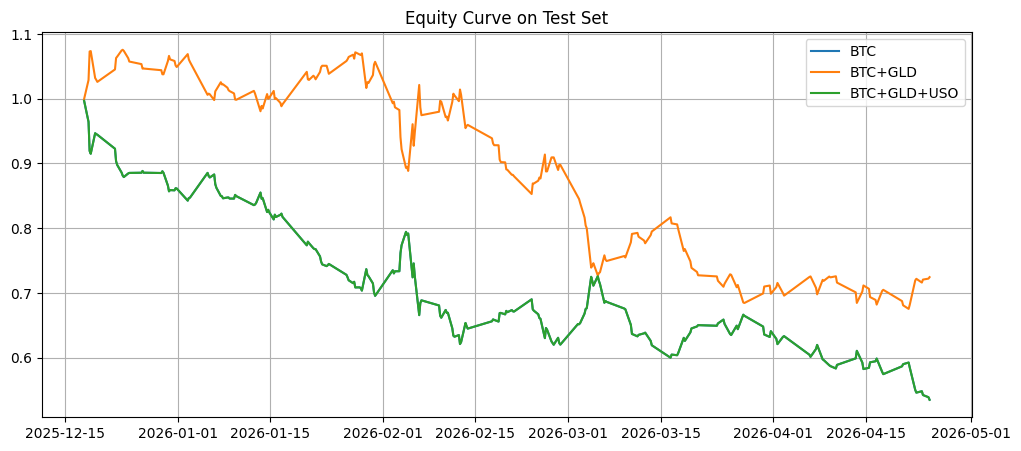

In [25]:
plt.figure(figsize=(12, 5))
plt.plot(results_btc.index, results_btc["equity"], label="BTC")
plt.plot(results_btc_gld.index, results_btc_gld["equity"], label="BTC+GLD")
plt.plot(results_btc_gld_uso.index, results_btc_gld_uso["equity"], label="BTC+GLD+USO")
plt.title("Equity Curve on Test Set")
plt.legend()
plt.grid(True)
plt.show()

## 15. Guardat de resultats

In [26]:
results_dir = project_root / "results"
results_dir.mkdir(exist_ok=True)

results_btc.to_csv(results_dir / "results_macro_btc_holding.csv")
results_btc_gld.to_csv(results_dir / "results_macro_btc_gld_holding.csv")
results_btc_gld_uso.to_csv(results_dir / "results_macro_btc_gld_uso_holding.csv")
comparison.to_csv(results_dir / "comparison_macro_gld_uso_holding.csv")

print("Results saved in:", results_dir)

Results saved in: c:\Users\rfran\OneDrive\Documentos\UOC\Master\TFM\tfm-drl-trading\results


In [27]:
print(
    (results_btc["equity"] - results_btc_gld_uso["equity"]).abs().sum()
)

0.0
